In [1]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import os
import sys

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))

if project_root not in sys.path:
    sys.path.append(project_root)

from IPython.display import Audio
from convex_nmf import ConvexNMF
from utils import compute_sparsity, calc_snr
from standard_nmf import StandardNMF

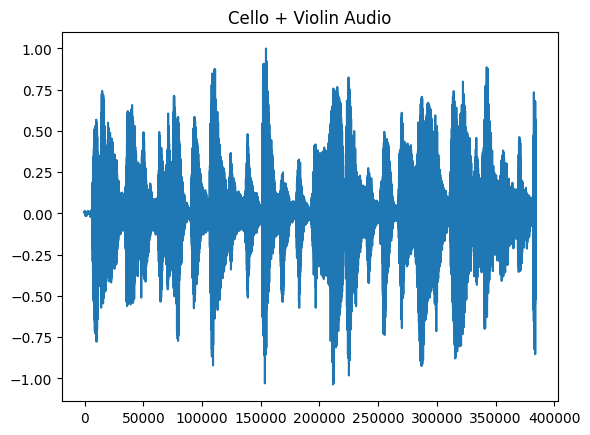

In [2]:
path = '/Users/jasonluo/Documents/JL School/ENEE469O/final_project/data_files/cello_violin_duet.wav'
mixed_signal, sample_rate = librosa.load(path, sr = None)
mixed_signal = mixed_signal[(sample_rate * 7):(sample_rate * 15)]
mixed_signal = mixed_signal / np.abs(np.max(mixed_signal))
display(Audio(mixed_signal, rate = sample_rate))

plt.plot(mixed_signal)
plt.title('Cello + Violin Audio')
plt.show()

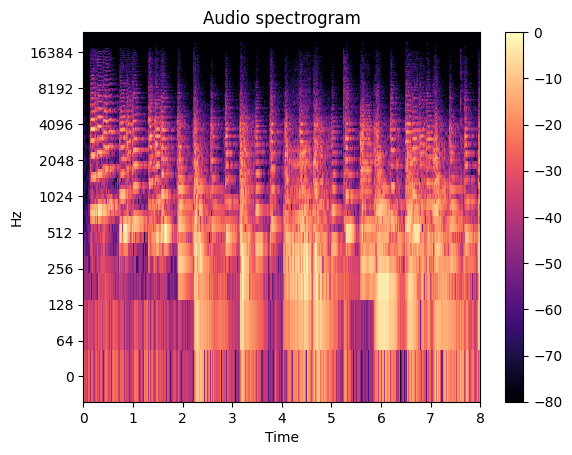

In [3]:
frame_length = 512
hop_length = int(frame_length * 0.25)
sound_stft = librosa.stft(mixed_signal, n_fft=frame_length, hop_length=hop_length)

sound_stft_Magnitude = np.abs(sound_stft)
sound_stft_Angle = np.angle(sound_stft) #Phase

#Plot Log-Scale Spectogram
Spec = librosa.amplitude_to_db(sound_stft_Magnitude, ref = np.max)
img = librosa.display.specshow(Spec,y_axis = 'log',sr=sample_rate,hop_length=hop_length,x_axis ='time')
plt.title('Audio spectrogram')
plt.colorbar(img)
plt.show()

## Convex NMF
In general, convex NMF takes signifiantly longer than the standard NMF due to the increased number of matrix multiplications. 

  3%|▎         | 126/5000 [02:49<1:49:10,  1.34s/it]

Convergence achieved at iteration 126...


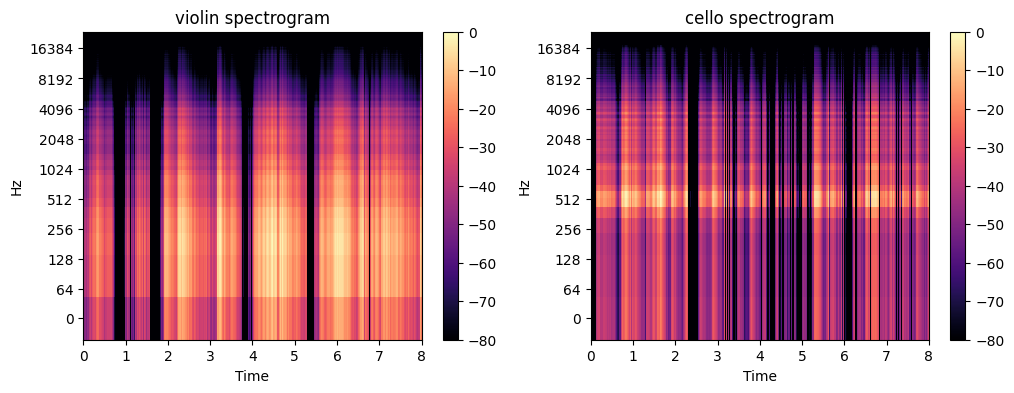

In [4]:
num_sources = 2
CNMF = ConvexNMF(sound_stft_Magnitude, num_sources, 1e-4, 5000, random_state=10)
F, W, G_T, residual_vector_convex = CNMF.factorize()
instruments = ['violin', 'cello']


# Constructing estimated filtered spectrograms
filtered_spectrograms = []
fig, axs = plt.subplots(1, num_sources, figsize = [12, 4])
for i in range(0, num_sources):
    filtered_spectrogram = F[:,[i]] @ G_T[[i],:] # ith Column of W * ith row of H
    D = librosa.amplitude_to_db(filtered_spectrogram, ref = np.max)
    img = librosa.display.specshow(D,y_axis = 'log',sr=sample_rate,hop_length=hop_length,x_axis ='time', ax = axs[i])
    axs[i].set_title(f"{instruments[i]} spectrogram")
    fig.colorbar(img)
    
    filtered_spectrograms.append(filtered_spectrogram)

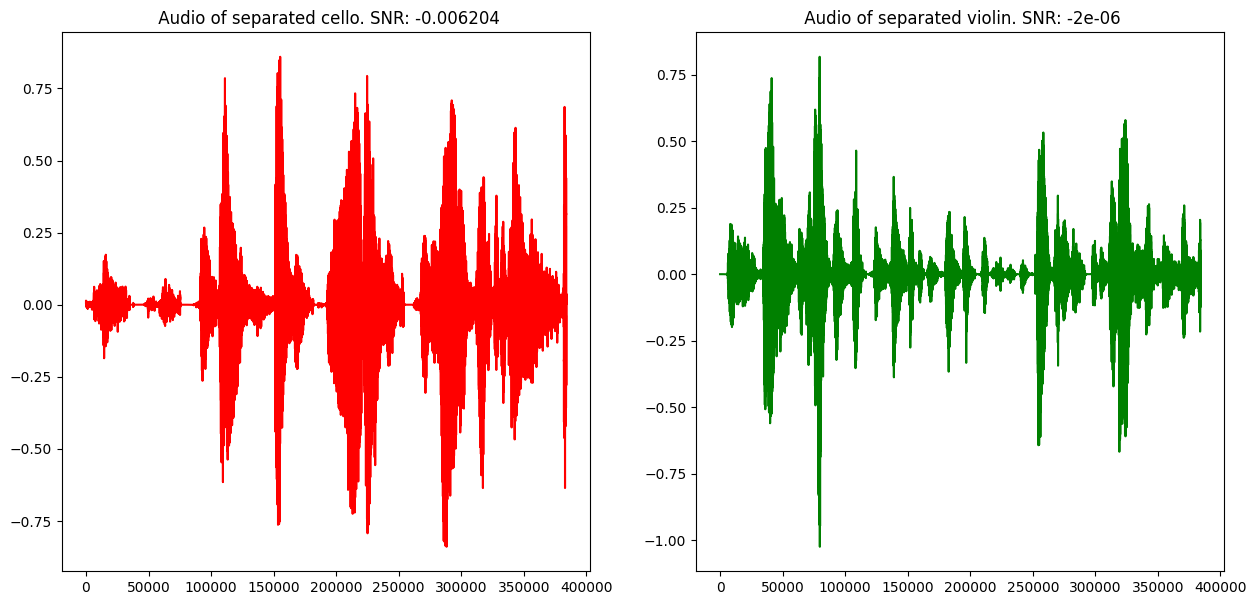

In [5]:
# Contructing source sounds using filtered spectograms and phase
new_sounds = []
colors = ['r', 'g']
instruments = ['cello', 'violin']

fig, axs = plt.subplots(1, num_sources, figsize = [15, 7])

for i in range(0, num_sources):
    reconstruct = filtered_spectrograms[i] * np.exp(1j*sound_stft_Angle)
    new_sound = librosa.istft(reconstruct, n_fft = frame_length, hop_length = hop_length)
    new_sounds.append(new_sound)
    axs[i].plot(new_sound, color = colors[i])
    axs[i].set_title(f" Audio of separated {instruments[i]}. SNR: {np.round(calc_snr(mixed_signal, new_sound[i]), 6)}")
    
    display(Audio(new_sounds[i], rate = sample_rate))

In [6]:
G_T_sparse, num_non_zero_G = compute_sparsity(G_T)
F_sparse, num_non_zero_F = compute_sparsity(F)
print(f'Proportion of non-zero elements in  G^T and F: {num_non_zero_G}, {num_non_zero_F}')

for i in range(2):
    __, num_non_zero = compute_sparsity(F[:,[i]] @ G_T[[i], :])
    print(f"Proportion of non-zero elements in spectrogram {i+1} : {num_non_zero} \n")

Proportion of non-zero elements in  G^T and F: 0.888537154281906, 0.8346303501945526
Proportion of non-zero elements in spectrogram 1 : 0.8365758754863813 

Proportion of non-zero elements in spectrogram 2 : 0.8326848249027238 



## Standard NMF
Note ```scikit-learn``` has its own implementation of NMF: ```from sklearn.decomposition import NMF```

  0%|          | 25/5000 [00:00<01:06, 75.08it/s]


Convergence achieved at iteration 25...


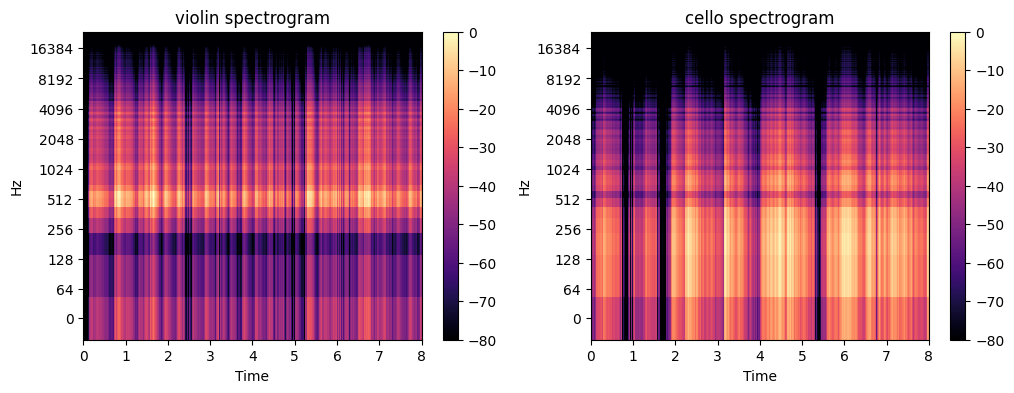

In [7]:
num_sources = 2
model = StandardNMF(sound_stft_Magnitude, num_bases=num_sources, n_iter=5000, tol = 1e-4, random_state = 100)
W, H, residual_vector_standard = model.factorize()
instruments = ['violin', 'cello']

# Constructing estimated filtered spectrograms
filtered_spectrograms = []
fig, axs = plt.subplots(1, num_sources, figsize = [12,4])
for i in range(0, num_sources):
    filtered_spectrogram = W[:,[i]] @ H[[i],:] # ith Column of W * ith row of H
    D = librosa.amplitude_to_db(filtered_spectrogram, ref = np.max)
    img = librosa.display.specshow(D,y_axis = 'log',sr=sample_rate,hop_length=hop_length,x_axis ='time', ax = axs[i])
    axs[i].set_title(f"{instruments[i]} spectrogram")
    fig.colorbar(img)
    
    filtered_spectrograms.append(filtered_spectrogram)

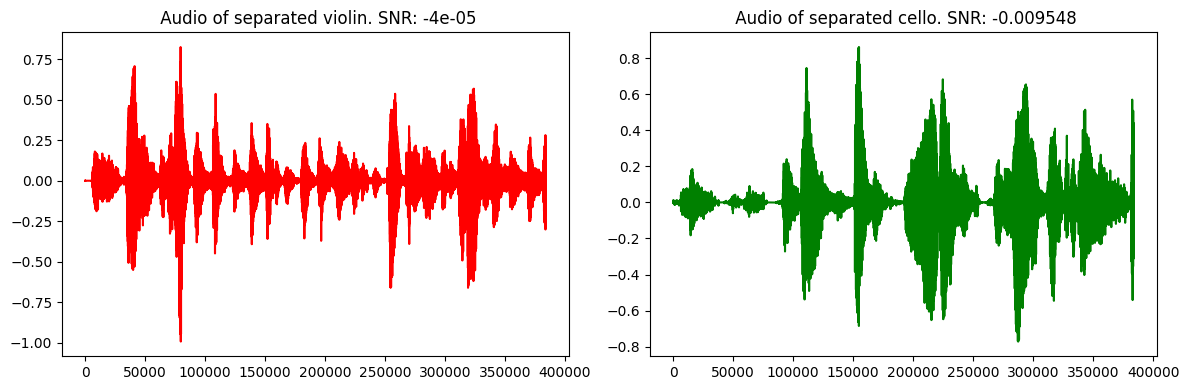

In [8]:
new_sounds = []
colors = ['r', 'g']
instruments = ['violin', 'cello']

fig, axs = plt.subplots(1, num_sources, figsize = [12 ,4])

for i in range(0, num_sources):
    reconstruct = filtered_spectrograms[i] * np.exp(1j*sound_stft_Angle)
    new_sound = librosa.istft(reconstruct, n_fft = frame_length, hop_length = hop_length)
    new_sounds.append(new_sound)
    axs[i].plot(new_sound, color = colors[i])
    
    axs[i].set_title(f" Audio of separated {instruments[i]}. SNR: {np.round(calc_snr(mixed_signal, new_sound[i]), 6)}")
    display(Audio(new_sounds[i], rate = sample_rate))

plt.tight_layout()

In [9]:
W_sparse, num_non_zero_W = compute_sparsity(W)
H_sparse, num_non_zero_H = compute_sparsity(H)
print(f'Proportion of non-zero elements in  W and H: {num_non_zero_W}, {num_non_zero_H}')

for i in range(2):
    __, num_non_zero = compute_sparsity(W[:,[i]] @ H[[i],:])
    print(f"Proportion of non-zero elements in spectrogram {i+1} : {num_non_zero} \n")

Proportion of non-zero elements in  W and H: 0.8346303501945526, 0.9791736087970676
Proportion of non-zero elements in spectrogram 1 : 0.8326848249027238 

Proportion of non-zero elements in spectrogram 2 : 0.8365758754863813 



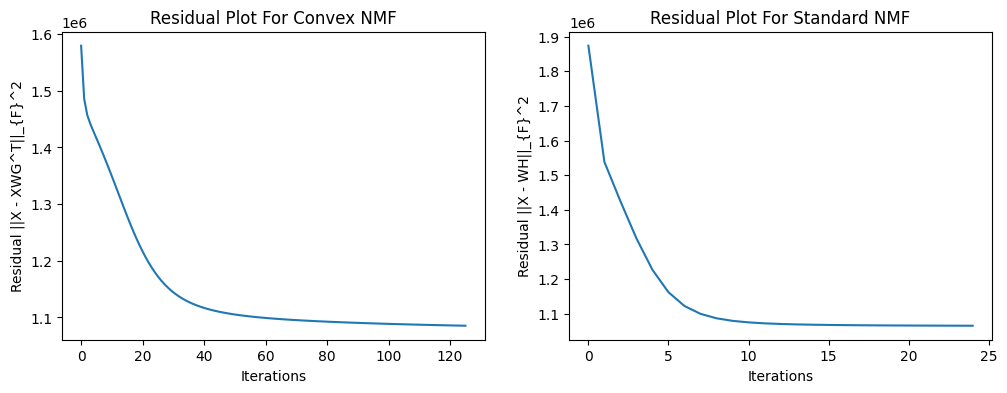

In [10]:
fig, axs = plt.subplots(1, 2, figsize = [12,4])

axs[0].plot(residual_vector_convex)
axs[0].set_title('Residual Plot For Convex NMF')
axs[0].set_xlabel('Iterations')
axs[0].set_ylabel('Residual ||X - XWG^T||_{F}^2')

axs[1].plot(residual_vector_standard)
axs[1].set_title('Residual Plot For Standard NMF')
axs[1].set_xlabel('Iterations')
axs[1].set_ylabel('Residual ||X - WH||_{F}^2')

plt.show()